**G05:** Jakober, Matzinger, Winkler, Salzmann

In [1]:
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
import random
from torch import nn
from torchsummary import summary
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [3]:
with open("companies.csv", encoding="UTF-8") as corpus_file:
    corpus = corpus_file.read()
    corpus_length = len(corpus)

print(f"Loaded a corpus of {corpus_length} characters")

Loaded a corpus of 2567986 characters


In [4]:
chars = sorted(list(set(corpus)))
num_chars = len(chars)
encoding = {c: i for i, c in enumerate(chars)}
decoding = {i: c for i, c in enumerate(chars)}
print(f"Our corpus contains {num_chars} characters")

Our corpus contains 150 characters


In [5]:
print(decoding)
print(encoding)

{0: '\n', 1: ' ', 2: '!', 3: '"', 4: '#', 5: '$', 6: '%', 7: '&', 8: "'", 9: '(', 10: ')', 11: '*', 12: '+', 13: ',', 14: '-', 15: '.', 16: '/', 17: '0', 18: '1', 19: '2', 20: '3', 21: '4', 22: '5', 23: '6', 24: '7', 25: '8', 26: '9', 27: ':', 28: '=', 29: '>', 30: '?', 31: '@', 32: 'A', 33: 'B', 34: 'C', 35: 'D', 36: 'E', 37: 'F', 38: 'G', 39: 'H', 40: 'I', 41: 'J', 42: 'K', 43: 'L', 44: 'M', 45: 'N', 46: 'O', 47: 'P', 48: 'Q', 49: 'R', 50: 'S', 51: 'T', 52: 'U', 53: 'V', 54: 'W', 55: 'X', 56: 'Y', 57: 'Z', 58: '[', 59: '\\', 60: ']', 61: '^', 62: '_', 63: 'a', 64: 'b', 65: 'c', 66: 'd', 67: 'e', 68: 'f', 69: 'g', 70: 'h', 71: 'i', 72: 'j', 73: 'k', 74: 'l', 75: 'm', 76: 'n', 77: 'o', 78: 'p', 79: 'q', 80: 'r', 81: 's', 82: 't', 83: 'u', 84: 'v', 85: 'w', 86: 'x', 87: 'y', 88: 'z', 89: '{', 90: '|', 91: '}', 92: '~', 93: '\x81', 94: '\x82', 95: '\x83', 96: '\x84', 97: '\x85', 98: '\x86', 99: '\x87', 100: '\x88', 101: '\x89', 102: '\x8a', 103: '\x8b', 104: '\x8c', 105: '\x8d', 106: '\x

# Many to One Approach

In [6]:
seq_length = 10
skip = 3
X_data = []
y_data = []
for i in range(0, len(corpus) - seq_length, skip):
    sentence = corpus[i: i + seq_length]
    next_char = corpus[i + seq_length]
    X_data.append([encoding[char] for char in sentence])
    y_data.append(encoding[next_char])

num_sentences = len(X_data)
print(f"Sliced our corpus into {num_sentences} sentences of length {seq_length}")

Sliced our corpus into 855992 sentences of length 10


In [7]:
print(X_data[0])
print([decoding[idx] for idx in X_data[0]])
print(decoding[y_data[0]])

[39, 63, 81, 70, 78, 74, 63, 87, 1, 40]
['H', 'a', 's', 'h', 'p', 'l', 'a', 'y', ' ', 'I']
n


In [8]:
X = F.one_hot(torch.tensor(X_data), num_classes=num_chars).to(torch.float32)
y = torch.tensor(y_data)

print(f"Sanity check y. Dimension: {y.shape} # Sentences: {num_sentences} Characters in corpus: {len(chars)}")
print(f"Sanity check X. Dimension: {X.size()} Sentence length: {seq_length}")

Sanity check y. Dimension: torch.Size([855992]) # Sentences: 855992 Characters in corpus: 150
Sanity check X. Dimension: torch.Size([855992, 10, 150]) Sentence length: 10


In [9]:
class RNNModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes):
        super(RNNModel, self).__init__()

        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True)
        self.linear = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        x, _ = self.rnn(x)
        return self.linear(x[:, -1])

In [10]:
hidden_size = 256
num_layers = 1
batch_size = 128

model = RNNModel(num_chars, hidden_size, num_layers, num_chars).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

summary(model, input_size=(batch_size, num_chars))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
               RNN-1  [[-1, 128, 256], [-1, 2, 256]]               0
            Linear-2                  [-1, 150]          38,550
Total params: 38,550
Trainable params: 38,550
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.07
Forward/backward pass size (MB): 128.00
Params size (MB): 0.15
Estimated Total Size (MB): 128.22
----------------------------------------------------------------


In [11]:
model

RNNModel(
  (rnn): RNN(150, 256, batch_first=True)
  (linear): Linear(in_features=256, out_features=150, bias=True)
)

In [12]:
def train(epoch, model, data_loader):
    model.train()
    total_train_loss = 0
    total_correct = 0

    for batch_idx, (data, target) in enumerate(tqdm(data_loader, desc=f"Training Epoch {epoch}")):
        data = data.to(device)
        target = target.to(device)
        optimizer.zero_grad()

        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()
        _, pred = torch.max(output, dim=1)
        total_correct += torch.sum(pred == target).item()

    accuracy_train = total_correct / len(data_loader.dataset)

    total_train_loss = total_train_loss / len(data_loader)

    return {
        "loss": total_train_loss,
        "accuracy": accuracy_train,
    }

In [13]:
@torch.inference_mode()
def predict(model, data):
    model.eval()
    output = model(data)
    return output

In [14]:
dataset = TensorDataset(X, y)
train_loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

In [38]:
train_losses = []
train_accuracies = []

epochs = 10
for epoch in range(1, epochs + 1):
    train_result = train(epoch, model, train_loader)
    train_losses.append(train_result["loss"])
    train_accuracies.append(train_result["accuracy"])

Training Epoch 10: 100%|██████████| 6688/6688 [00:39<00:00, 167.87it/s]


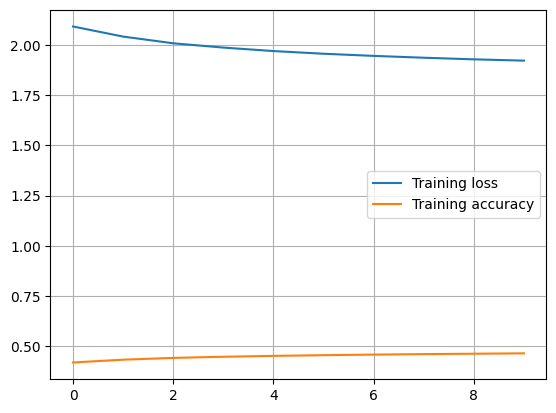

In [41]:
plt.plot(train_losses, label='Training loss')
plt.plot(train_accuracies, label='Training accuracy')
plt.legend()
plt.grid()

In [16]:
def make_seed(seed_phrase=""):
    if seed_phrase:
        phrase_length = len(seed_phrase)
        pattern = ""
        for i in range (0, seq_length):
            pattern += seed_phrase[i % phrase_length]
    else:
        seed = random.randint(0, corpus_length - seq_length)
        pattern = corpus[seed:seed + seq_length]
    return pattern


seed_pattern = make_seed("")
print("seed = " + seed_pattern)

def get_name_for_seed(seed_pattern, generation_model):
    encoded_text = torch.tensor([encoding[char] for char in seed_pattern])
    encoded_text = F.one_hot(encoded_text, num_classes=num_chars).to(torch.float)
    # Add a single batch dimension at the beginning
    encoded_text = encoded_text.unsqueeze(0)
    encoded_text = encoded_text.to(device)

    generated_text = ""
    for i in range(12):
        # predict() gives a tensor of shape (1, 65)
        # with 1 being the size of the batch, for that we use [0] to get a vector
        output = predict(generation_model, encoded_text)[0]
        # Convert the output to probabilities
        probs = torch.softmax(output, dim=-1)
        # Randomly choose from a multinomial distribution with the output probabilities
        # make the generation more diverse.
        prediction = torch.multinomial(probs, num_samples=1)
        generated_text += decoding[int(prediction)]

        # One hot encode the new (predicted) character
        next_char_encoded = F.one_hot(prediction, num_classes=num_chars)
        # Make sure it has a singular batch and seq_len dimension in order to concatenate them.
        next_char_encoded = next_char_encoded.view(1, 1, num_chars)
        # Remove first char and glue the predicted one to the end
        encoded_text = torch.cat((encoded_text[:, 1:], next_char_encoded), dim=1)
    return generated_text
print(get_name_for_seed(seed_pattern, model))

seed = GROOVE X, 
eìì/YûUÕh


In [105]:
params = [
    {
        'n_epochs': 8,
        'hidden_size': 128
    },
    {
        'n_epochs': 12,
        'hidden_size': 128
    },
    {
        'n_epochs': 8,
        'hidden_size': 256
    },
    {
        'n_epochs': 12,
        'hidden_size': 256
    },
    {
        'n_epochs': 8,
        'hidden_size': 512
    },
    {
        'n_epochs': 12,
        'hidden_size': 512
    }
]

seed = make_seed("Int.")

for setting in params:
    n_epochs = setting["n_epochs"]
    hidden_size = setting["hidden_size"]
    model = RNNModel(num_chars, hidden_size, num_layers, num_chars).to(device)
    for epoch in range(1, n_epochs + 1):
        train_result = train(epoch, model, train_loader)

    print(f"Generated name for Hidden Size {hidden_size} after {n_epochs} epochs: {get_name_for_seed(seed, model)}")

Training Epoch 4:  87%|████████▋ | 5804/6688 [00:32<00:05, 176.22it/s]


KeyboardInterrupt: 

# Many to Many

In [47]:
class mmRNNModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes):
        super(mmRNNModel, self).__init__()

        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True)
        self.linear = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        x, _ = self.rnn(x)
        x = x[:, -1, :]
        return self.linear(x)

In [48]:
hidden_size = 256
num_layers = 1
batch_size = 128

mmModel = mmRNNModel(num_chars, hidden_size, num_layers, num_chars).to(device)
optimizer = torch.optim.Adam(mmModel.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

summary(mmModel, input_size=(batch_size, num_chars))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
               RNN-1  [[-1, 128, 256], [-1, 2, 256]]               0
            Linear-2                  [-1, 150]          38,550
Total params: 38,550
Trainable params: 38,550
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.07
Forward/backward pass size (MB): 128.00
Params size (MB): 0.15
Estimated Total Size (MB): 128.22
----------------------------------------------------------------


In [51]:
def train(epoch, model, data_loader):
    model.train()
    total_train_loss = 0
    total_correct = 0

    for batch_idx, (data, target) in enumerate(tqdm(data_loader, desc=f"Training Epoch {epoch}")):
        data = data.to(device)
        target = target.to(device)
        optimizer.zero_grad()

        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()
        _, pred = torch.max(output, dim=1)
        total_correct += torch.sum(pred == target).item()

    accuracy_train = total_correct / len(data_loader.dataset)

    total_train_loss = total_train_loss / len(data_loader)

    return {
        "loss": total_train_loss,
        "accuracy": accuracy_train,
    }

In [52]:
train_losses = []
train_accuracies = []

epochs = 10
for epoch in range(1, epochs + 1):
    train_result = train(epoch, mmModel, train_loader)
    train_losses.append(train_result["loss"])
    train_accuracies.append(train_result["accuracy"])

Training Epoch 10: 100%|██████████| 6688/6688 [01:09<00:00, 96.46it/s] 


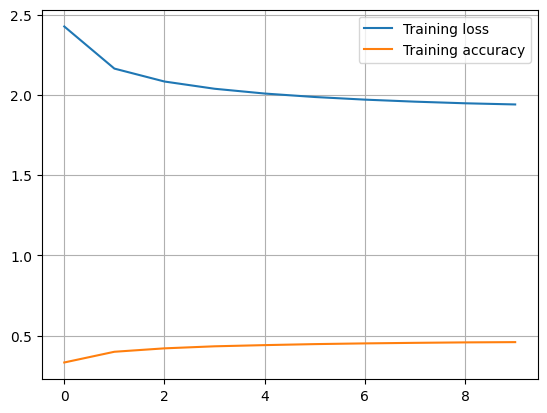

In [53]:
plt.plot(train_losses, label='Training loss')
plt.plot(train_accuracies, label='Training accuracy')
plt.legend()
plt.grid()

In [84]:
get_name_for_seed("Int. ", mmModel)

'Group In Inc'